# Test COCO Data Loader

Este notebook verifica que el `COCOLoader` funciona correctamente:
- ✅ Carga de anotaciones COCO
- ✅ Iteración sobre imágenes
- ✅ Parsing de keypoints (17 puntos)
- ✅ Visualización de imágenes con keypoints
- ✅ Estadísticas del dataset

## 1. Importar Librerías

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Añadir el directorio src al path
sys.path.insert(0, os.path.abspath('../src'))

from pose_uncertainty.data_loader import COCOLoader
from pose_uncertainty.utils.types import ImageSample, Keypoint

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Configurar Rutas del Dataset

In [2]:
# Rutas del dataset COCO
DATA_ROOT = '../data/coco'
ANN_FILE = 'annotations/person_keypoints_val2017.json'
IMAGE_DIR = 'val2017'

print(f"📁 Ruta base: {DATA_ROOT}")
print(f"📄 Anotaciones: {ANN_FILE}")
print(f"🖼️  Imágenes: {IMAGE_DIR}")

📁 Ruta base: ../data/coco
📄 Anotaciones: annotations/person_keypoints_val2017.json
🖼️  Imágenes: val2017


## 3. Inicializar COCO Loader

In [3]:
# Crear instancia del loader
loader = COCOLoader(
    data_root=DATA_ROOT,
    ann_file=ANN_FILE,
    image_dir=IMAGE_DIR
)

print(f"\n✅ Dataset cargado: {len(loader)} imágenes disponibles")

Cargando anotaciones desde ../data/coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=0.55s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.

✅ Dataset cargado: 2693 imágenes disponibles


## 4. Cargar Muestras del Dataset

In [4]:
# Cargar las primeras 3 muestras
samples = []
for i, sample in enumerate(loader):
    if i >= 3:
        break
    samples.append(sample)
    print(f"\n📸 Muestra {i+1}:")
    print(f"   ID: {sample.image_id}")
    print(f"   Shape: {sample.image_array.shape}")
    print(f"   BBox: {sample.bbox}")
    print(f"   Keypoints: {len(sample.ground_truth_keypoints)}")
    
print(f"\n✅ {len(samples)} muestras cargadas correctamente")


📸 Muestra 1:
   ID: 532481
   Shape: (426, 640, 3)
   BBox: (250.82, 168.26, 70.11, 64.88)
   Keypoints: 17

📸 Muestra 2:
   ID: 458755
   Shape: (480, 640, 3)
   BBox: (69.03, 37.75, 508.05, 435.78)
   Keypoints: 17

📸 Muestra 3:
   ID: 385029
   Shape: (480, 640, 3)
   BBox: (0, 308.49, 272.9, 170.43)
   Keypoints: 17

✅ 3 muestras cargadas correctamente


## 5. Visualizar Imágenes con Keypoints


MUESTRA 1


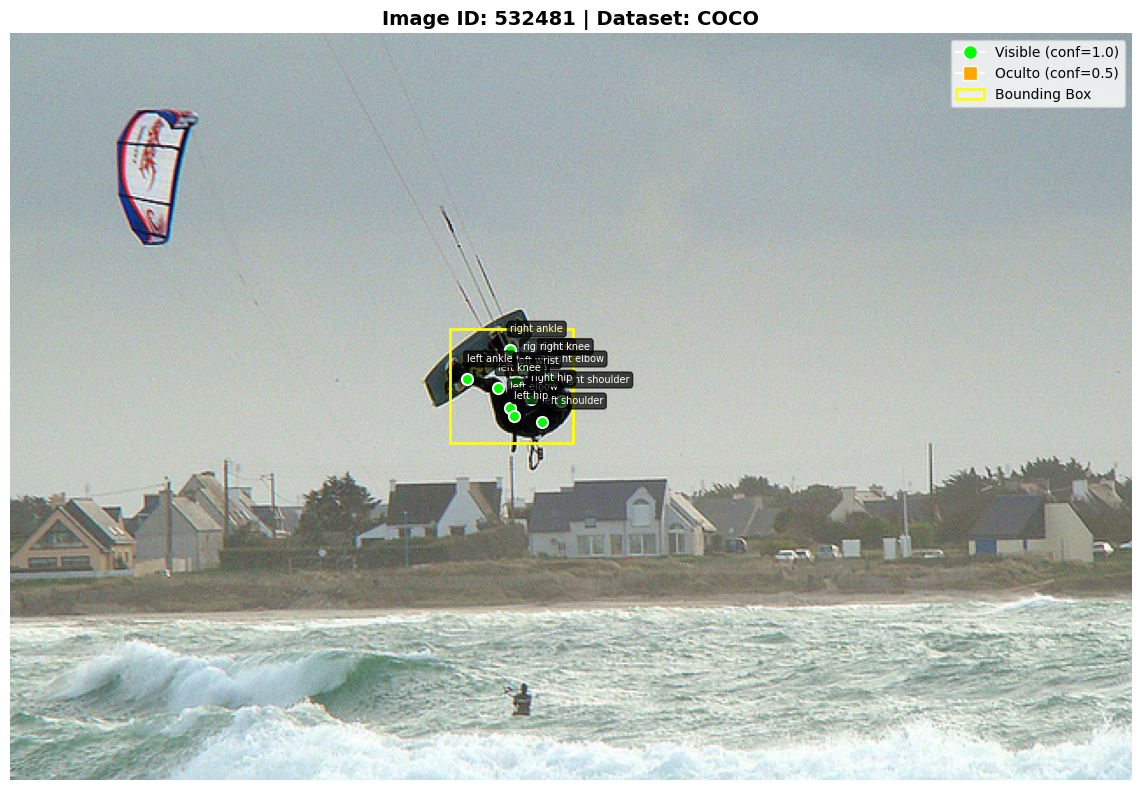


MUESTRA 2


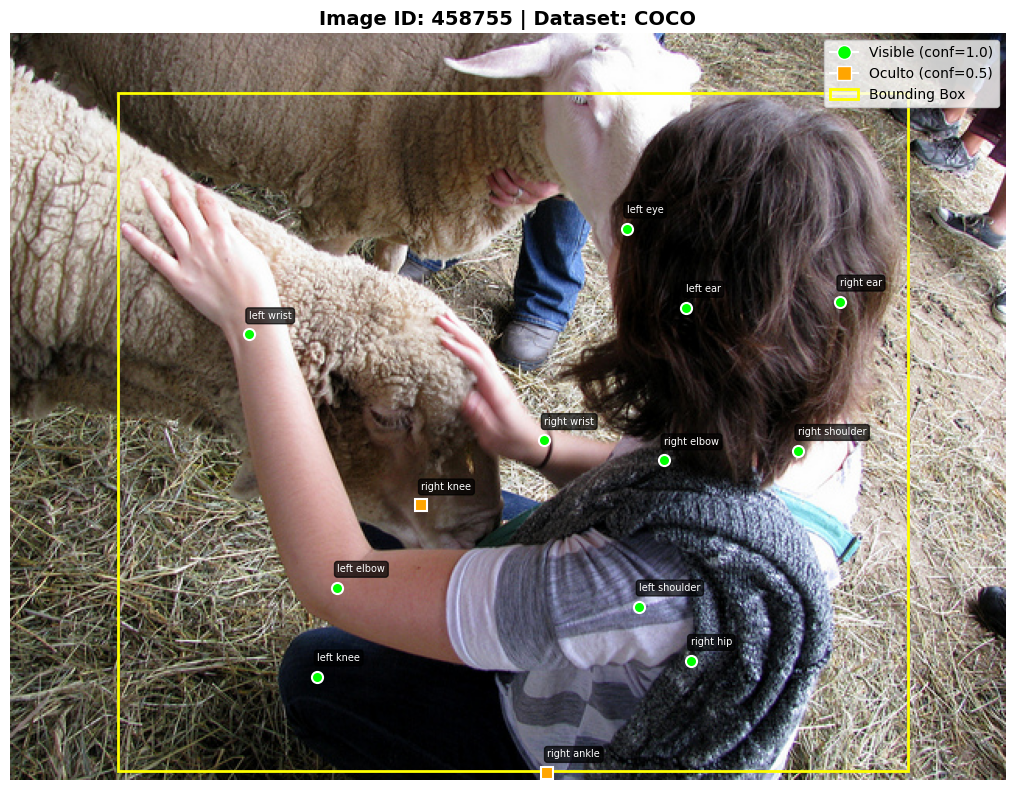


MUESTRA 3


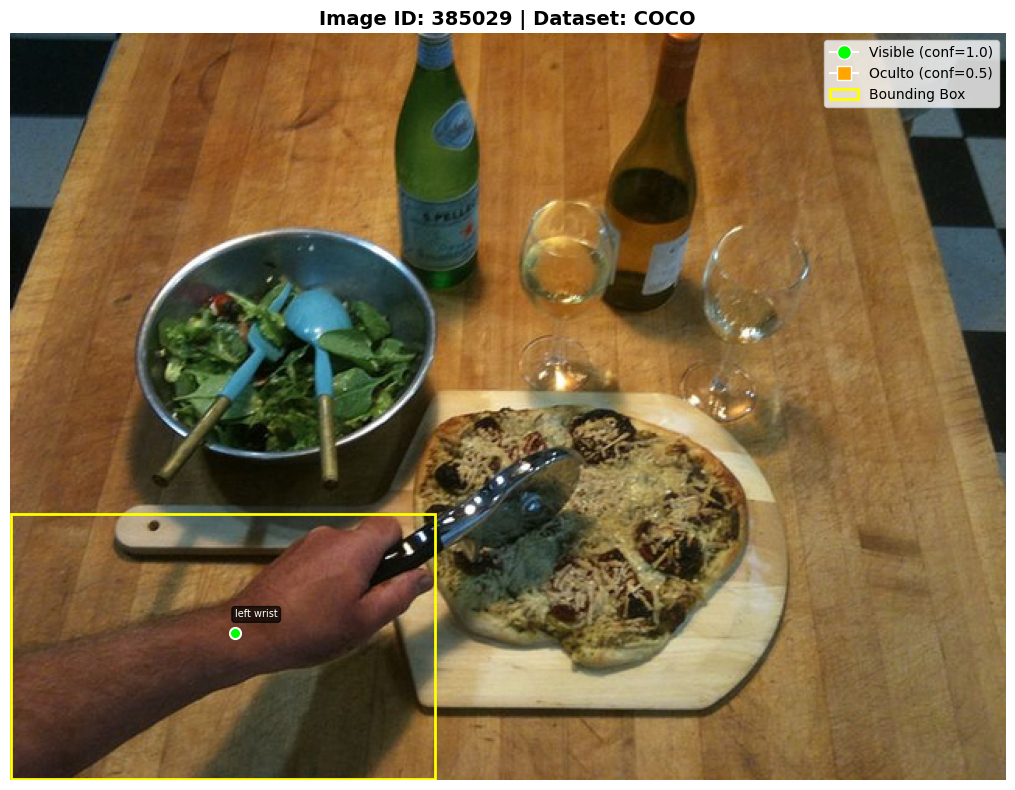

In [5]:
def visualize_sample(sample: ImageSample, show_bbox=True, show_keypoints=True):
    """Visualiza una muestra con su bbox y keypoints."""
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(sample.image_array)
    
    # Dibujar bounding box
    if show_bbox:
        x, y, w, h = sample.bbox
        rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)
    
    # Dibujar keypoints
    if show_keypoints:
        for kp in sample.ground_truth_keypoints:
            if kp.confidence > 0:  # Solo dibujar keypoints etiquetados
                # Color según visibilidad
                if kp.confidence == 1.0:
                    color = 'lime'  # Visible
                    marker = 'o'
                elif kp.confidence == 0.5:
                    color = 'orange'  # Oculto
                    marker = 's'
                else:
                    continue  # No etiquetado
                
                ax.plot(kp.x, kp.y, marker, color=color, markersize=8, 
                       markeredgecolor='white', markeredgewidth=1.5)
                ax.text(kp.x, kp.y-10, kp.name.replace('_', ' '), 
                       fontsize=7, color='white', 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    ax.set_title(f"Image ID: {sample.image_id} | Dataset: {sample.dataset_source.upper()}", 
                fontsize=14, fontweight='bold')
    ax.axis('off')
    
    # Leyenda
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lime', markersize=10, label='Visible (conf=1.0)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', markersize=10, label='Oculto (conf=0.5)'),
        Rectangle((0, 0), 1, 1, fc='none', ec='yellow', lw=2, label='Bounding Box')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Visualizar las 3 muestras
for i, sample in enumerate(samples):
    print(f"\n{'='*60}")
    print(f"MUESTRA {i+1}")
    print(f"{'='*60}")
    visualize_sample(sample)

## 6. Verificar Estructura de Keypoints

In [6]:
# Inspeccionar los keypoints de la primera muestra
sample = samples[0]

print(f"📊 Análisis de Keypoints - Muestra 1 (ID: {sample.image_id})")
print(f"{'='*70}")
print(f"{'ID':<4} {'Nombre':<20} {'X':<8} {'Y':<8} {'Conf':<8} {'Estado'}")
print(f"{'='*70}")

for kp in sample.ground_truth_keypoints:
    if kp.confidence == 1.0:
        estado = "✅ Visible"
    elif kp.confidence == 0.5:
        estado = "⚠️  Oculto"
    else:
        estado = "❌ No etiquetado"
    
    print(f"{kp.id:<4} {kp.name:<20} {kp.x:<8.1f} {kp.y:<8.1f} {kp.confidence:<8.1f} {estado}")

print(f"{'='*70}")

# Contar keypoints por estado
visible = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 1.0)
oculto = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.5)
no_etiquetado = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.0)

print(f"\n📈 Resumen:")
print(f"   ✅ Visibles: {visible}/17")
print(f"   ⚠️  Ocultos: {oculto}/17")
print(f"   ❌ No etiquetados: {no_etiquetado}/17")

📊 Análisis de Keypoints - Muestra 1 (ID: 532481)
ID   Nombre               X        Y        Conf     Estado
0    nose                 0.0      0.0      0.0      ❌ No etiquetado
1    left_eye             0.0      0.0      0.0      ❌ No etiquetado
2    right_eye            0.0      0.0      0.0      ❌ No etiquetado
3    left_ear             0.0      0.0      0.0      ❌ No etiquetado
4    right_ear            0.0      0.0      0.0      ❌ No etiquetado
5    left_shoulder        303.0    221.0    1.0      ✅ Visible
6    right_shoulder       314.0    209.0    1.0      ✅ Visible
7    left_elbow           285.0    213.0    1.0      ✅ Visible
8    right_elbow          307.0    197.0    1.0      ✅ Visible
9    left_wrist           288.0    198.0    1.0      ✅ Visible
10   right_wrist          292.0    190.0    1.0      ✅ Visible
11   left_hip             287.0    218.0    1.0      ✅ Visible
12   right_hip            297.0    208.0    1.0      ✅ Visible
13   left_knee            278.0    202.0  

## 7. Estadísticas del Dataset

In [8]:
# Calcular estadísticas sobre las muestras cargadas
print("📊 Estadísticas del Dataset (primeras 3 muestras)")
print(f"{'='*60}")

# Estadísticas por muestra
for i, sample in enumerate(samples):
    visible = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 1.0)
    oculto = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.5)
    total_etiquetado = visible + oculto
    
    print(f"\nMuestra {i+1} (ID: {sample.image_id}):")
    print(f"   Shape: {sample.image_array.shape}")
    print(f"   Keypoints visibles: {visible}/17 ({visible/17*100:.1f}%)")
    print(f"   Keypoints ocultos: {oculto}/17 ({oculto/17*100:.1f}%)")
    print(f"   Total etiquetados: {total_etiquetado}/17 ({total_etiquetado/17*100:.1f}%)")

# Estadísticas globales
all_visible = sum(sum(1 for kp in s.ground_truth_keypoints if kp.confidence == 1.0) for s in samples)
all_oculto = sum(sum(1 for kp in s.ground_truth_keypoints if kp.confidence == 0.5) for s in samples)
total_keypoints = len(samples) * 17

print(f"\n{'='*60}")
print(f"📊 Estadísticas Globales:")
print(f"   Total muestras: {len(samples)}")
print(f"   Promedio keypoints visibles: {all_visible/len(samples):.1f}/17")
print(f"   Promedio keypoints ocultos: {all_oculto/len(samples):.1f}/17")
print(f"   Tasa de visibilidad: {all_visible/total_keypoints*100:.1f}%")

📊 Estadísticas del Dataset (primeras 3 muestras)

Muestra 1 (ID: 532481):
   Shape: (426, 640, 3)
   Keypoints visibles: 12/17 (70.6%)
   Keypoints ocultos: 0/17 (0.0%)
   Total etiquetados: 12/17 (70.6%)

Muestra 2 (ID: 458755):
   Shape: (480, 640, 3)
   Keypoints visibles: 11/17 (64.7%)
   Keypoints ocultos: 2/17 (11.8%)
   Total etiquetados: 13/17 (76.5%)

Muestra 3 (ID: 385029):
   Shape: (480, 640, 3)
   Keypoints visibles: 1/17 (5.9%)
   Keypoints ocultos: 0/17 (0.0%)
   Total etiquetados: 1/17 (5.9%)

📊 Estadísticas Globales:
   Total muestras: 3
   Promedio keypoints visibles: 8.0/17
   Promedio keypoints ocultos: 0.7/17
   Tasa de visibilidad: 47.1%


## 8. Verificar Lazy Loading

In [9]:
# Verificar que el lazy loading funciona correctamente
print("🔄 Verificando Lazy Loading...")
print(f"{'='*60}")

# El generador debe poder iterarse múltiples veces
print("\n🔁 Iteración 1:")
count_1 = 0
for i, sample in enumerate(loader):
    if i >= 5:
        break
    count_1 += 1
    print(f"   Muestra {i+1}: ID={sample.image_id}, Shape={sample.image_array.shape}")

print(f"\n✅ Primera iteración: {count_1} muestras")

print("\n🔁 Iteración 2 (debe funcionar igual):")
count_2 = 0
for i, sample in enumerate(loader):
    if i >= 5:
        break
    count_2 += 1
    print(f"   Muestra {i+1}: ID={sample.image_id}, Shape={sample.image_array.shape}")

print(f"\n✅ Segunda iteración: {count_2} muestras")

if count_1 == count_2:
    print("\n✅ Lazy loading funciona correctamente - se puede iterar múltiples veces")
else:
    print("\n⚠️  Advertencia: las iteraciones devolvieron diferentes números de muestras")

🔄 Verificando Lazy Loading...

🔁 Iteración 1:
   Muestra 1: ID=532481, Shape=(426, 640, 3)
   Muestra 2: ID=458755, Shape=(480, 640, 3)
   Muestra 3: ID=385029, Shape=(480, 640, 3)
   Muestra 4: ID=311303, Shape=(427, 640, 3)
   Muestra 5: ID=393226, Shape=(480, 640, 3)

✅ Primera iteración: 5 muestras

🔁 Iteración 2 (debe funcionar igual):
   Muestra 1: ID=532481, Shape=(426, 640, 3)
   Muestra 2: ID=458755, Shape=(480, 640, 3)
   Muestra 3: ID=385029, Shape=(480, 640, 3)
   Muestra 4: ID=311303, Shape=(427, 640, 3)
   Muestra 5: ID=393226, Shape=(480, 640, 3)

✅ Segunda iteración: 5 muestras

✅ Lazy loading funciona correctamente - se puede iterar múltiples veces


## ✅ Conclusión

El `COCOLoader` ha sido verificado exitosamente:

1. ✅ **Carga de anotaciones**: El archivo JSON se carga correctamente
2. ✅ **Iteración sobre imágenes**: El generador funciona y permite múltiples iteraciones
3. ✅ **Parsing de keypoints**: Los 17 keypoints COCO se convierten correctamente al formato `Keypoint`
4. ✅ **Mapeo de visibilidad**: Los valores de confianza (0.0, 0.5, 1.0) se asignan correctamente
5. ✅ **Lazy loading**: Las imágenes se cargan bajo demanda, evitando saturar la RAM
6. ✅ **Estructura de datos**: Los objetos `ImageSample` contienen toda la información necesaria

**Siguiente paso**: Usar este data loader en el pipeline de inferencia y TTA.